# Model Training 

In [14]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df_processed = pd.read_csv("final_sentiment_dataset.csv")
print("Dataset Shape:", df_processed.shape)

df_processed.head()

Dataset Shape: (1440, 25)


,title,rating,body,clean_title,clean_body,review_text,title_cleaned,body_cleaned,final_review_text,sentiment,...,review_tokens_cleaned,title_tokens_lemmatized,body_tokens_lemmatized,review_tokens_lemmatized,title_text_lemmatized,body_text_lemmatized,review_text_lemmatized,review_length,repeated_text,multilingual_type
0,Horrible product,1,Very disappointed with the overall performance...,horrible product,very disappointed with the overall performance...,horrible product very disappointed with the ov...,horrible product,very disappointed with the overall performance...,horrible product very disappointed with the ov...,negative,...,"['horrible', 'product', 'disappointed', 'overa...","['horrible', 'product']","['disappointed', 'overall', 'performance', 'sa...","['horrible', 'product', 'disappointed', 'overa...",horrible product,disappointed overall performance samsung,horrible product disappointed overall performa...,10,Normal,Single
1,Camera quality is not like 48 megapixel,3,Camera quality is low,camera quality is not like 48 megapixel,camera quality is low,camera quality is not like 48 megapixel camera...,camera quality is not like 48 megapixel,camera quality is low,camera quality is not like 48 megapixel camera...,neutral,...,"['camera', 'quality', 'not', 'like', '48', 'me...","['camera', 'quality', 'not', 'like', '48', 'me...","['camera', 'quality', 'low']","['camera', 'quality', 'not', 'like', '48', 'me...",camera quality not like 48 megapixel,camera quality low,camera quality not like 48 megapixel camera qu...,11,Normal,Single
2,Overall,4,"Got the mobile on the launch date,Battery must...",overall,got the mobile on the launch date battery must...,overall got the mobile on the launch date batt...,overall,got the mobile on the launch date battery must...,overall got the mobile on the launch date batt...,positive,...,"['overall', 'got', 'mobile', 'launch', 'date',...",['overall'],"['got', 'mobile', 'launch', 'date', 'battery',...","['overall', 'got', 'mobile', 'launch', 'date',...",overall,got mobile launch date battery must appreciate...,overall got mobile launch date battery must ap...,72,Normal,Single
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,a big no from me,1 it doesn t work with 5 0ghz wifi frequency 2...,a big no from me 1 it doesn t work with 5 0ghz...,a big no from me,1 it doesn t work with 5 0ghz wifi frequency 2...,a big no from me 1 it doesn t work with 5 0ghz...,negative,...,"['big', 'no', '1', 'work', '5', '0ghz', 'wifi'...","['big', 'no']","['1', 'work', '5', '0ghz', 'wifi', 'frequency'...","['big', 'no', '1', 'work', '5', '0ghz', 'wifi'...",big no,1 work 5 0ghz wifi frequency 2 4ghz old school...,big no 1 work 5 0ghz wifi frequency 2 4ghz old...,80,Normal,Single
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",put your money somewhere else,not worth buying faulty software poor display ...,put your money somewhere else not worth buying...,put your money somewhere else,not worth buying faulty software poor display ...,put your money somewhere else not worth buying...,negative,...,"['put', 'money', 'somewhere', 'else', 'not', '...","['put', 'money', 'somewhere', 'else']","['not', 'worth', 'buying', 'faulty', 'software...","['put', 'money', 'somewhere', 'else', 'not', '...",put money somewhere else,not worth buying faulty software poor display ...,put money somewhere else not worth buying faul...,36,Normal,Single


In [17]:
# CHECK COLUMNS
print(df_processed.columns)

Index(['title', 'rating', 'body', 'clean_title', 'clean_body', 'review_text',
       'title_cleaned', 'body_cleaned', 'final_review_text', 'sentiment',
       'title_tokens', 'body_tokens', 'review_tokens', 'title_tokens_cleaned',
       'body_tokens_cleaned', 'review_tokens_cleaned',
       'title_tokens_lemmatized', 'body_tokens_lemmatized',
       'review_tokens_lemmatized', 'title_text_lemmatized',
       'body_text_lemmatized', 'review_text_lemmatized', 'review_length',
       'repeated_text', 'multilingual_type'],
      dtype='object')


In [18]:
# FEATURES AND TARGET
# X -> input text
# y -> target labels

X = df_processed['body_cleaned']

y = df_processed['sentiment']

print(X.head())

print(y.head())

0    very disappointed with the overall performance...
1                                camera quality is low
2    got the mobile on the launch date battery must...
3    1 it doesn t work with 5 0ghz wifi frequency 2...
4    not worth buying faulty software poor display ...
Name: body_cleaned, dtype: object
0    negative
1     neutral
2    positive
3    negative
4    negative
Name: sentiment, dtype: object


In [19]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (1152,)
Testing Data: (288,)


In [20]:
# TF-IDF VECTORIZATION
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Train Shape:",
      X_train_tfidf.shape)

print("TF-IDF Test Shape:",
      X_test_tfidf.shape)

TF-IDF Train Shape: (1152, 5000)
TF-IDF Test Shape: (288, 5000)


# MODEL 2 - NAIVE BAYES

In [21]:
# NAIVE BAYES
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

print("\nNaive Bayes Model Trained Successfully")


Naive Bayes Model Trained Successfully


In [22]:
#Predictions
nb_pred = nb_model.predict(X_test_tfidf)

In [23]:
nb_accuracy = accuracy_score(y_test, nb_pred)
accuracy = accuracy_score(
    y_test,
    nb_pred
)

print("\nAccuracy Score:")
print(accuracy)




Accuracy Score:
0.7291666666666666


In [24]:
# PRECISION
precision = precision_score(
    y_test,
    nb_pred,
    average='weighted'
)

print("\nPrecision Score:")
print(precision)


Precision Score:
0.6395794428882664


C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [25]:
# RECALL
recall = recall_score(
    y_test,
    nb_pred,
    average='weighted'
)

print("\nRecall Score:")
print(recall)



Recall Score:
0.7291666666666666


In [26]:
# F1 SCORE
f1 = f1_score(
    y_test,
    nb_pred,
    average='weighted'
)

print("\nF1 Score:")
print(f1)


F1 Score:
0.6703097798259088


In [27]:
# CLASSIFICATION REPORT
cm = confusion_matrix(
    y_test,
    nb_pred
)

print("\nConfusion Matrix:\n")

print(cm)


Confusion Matrix:

[[ 68   0  34]
 [ 12   0  28]
 [  4   0 142]]


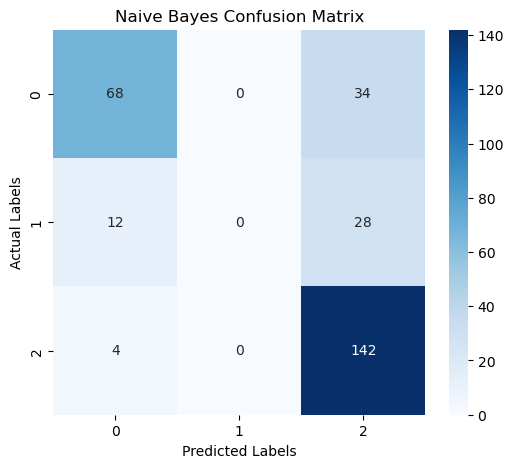

In [28]:
# CONFUSION MATRIX VISUALIZATION
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted Labels")

plt.ylabel("Actual Labels")

plt.show()

In [30]:
# HYPERPARAMETER TUNING
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

In [31]:
# TRAIN TUNED MODEL
grid_nb.fit(
    X_train_tfidf,
    y_train
)


Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]},
             scoring='f1_weighted', verbose=2)

In [32]:
# BEST PARAMETERS
print("\nBest Parameters:")
print(grid_nb.best_params_)



Best Parameters:
{'alpha': 0.1}


In [33]:
# BEST MODEL
best_nb_model = grid_nb.best_estimator_

In [34]:
# TUNED PREDICTIONS
best_nb_predictions = best_nb_model.predict(
    X_test_tfidf
)


In [36]:
# TUNED MODEL EVALUATION
print(" TUNED NAIVE BAYES MODEL ")
# Tuned Accuracy
tuned_accuracy = accuracy_score(
    y_test,
    best_nb_predictions
)

print("\nTuned Accuracy Score:")
print(tuned_accuracy)

# Tuned Precision
tuned_precision = precision_score(
    y_test,
    best_nb_predictions,
    average='weighted'
)
print("\nTuned Precision Score:")
print(tuned_precision)

# Tuned Recall
tuned_recall = recall_score(
    y_test,
    best_nb_predictions,
    average='weighted'
)

print("\nTuned Recall Score:")
print(tuned_recall)

# Tuned F1
tuned_f1 = f1_score(
    y_test,
    best_nb_predictions,
    average='weighted'
)
print("\nTuned F1 Score:")
print(tuned_f1)

# Tuned Classification Report
print("\nTuned Classification Report:\n")

print(classification_report(
    y_test,
    best_nb_predictions
))


 TUNED NAIVE BAYES MODEL 

Tuned Accuracy Score:
0.7673611111111112

Tuned Precision Score:
0.6631908777035895

Tuned Recall Score:
0.7673611111111112

Tuned F1 Score:
0.7109021571223657

Tuned Classification Report:

              precision    recall  f1-score   support

    negative       0.77      0.83      0.80       102
     neutral       0.00      0.00      0.00        40
    positive       0.77      0.93      0.84       146

    accuracy                           0.77       288
   macro avg       0.51      0.59      0.55       288
weighted avg       0.66      0.77      0.71       288



In [37]:
# MODEL COMPARISON
print(" MODEL COMPARISON ")
print(f"\nOriginal Accuracy : {accuracy:.4f}")
print(f"Tuned Accuracy    : {tuned_accuracy:.4f}")

print(f"\nOriginal F1 Score : {f1:.4f}")
print(f"Tuned F1 Score    : {tuned_f1:.4f}")


 MODEL COMPARISON 

Original Accuracy : 0.7292
Tuned Accuracy    : 0.7674

Original F1 Score : 0.6703
Tuned F1 Score    : 0.7109


In [38]:
# FINAL MODEL SELECTION
if tuned_f1 > f1:

    print("\nTuned Naive Bayes Model Performed Better")

    final_model = best_nb_model

else:

    print("\nOriginal Naive Bayes Model Performed Better")

    final_model = nb_model


Tuned Naive Bayes Model Performed Better


In [39]:
# SAVE FINAL MODEL
import joblib

joblib.dump(
    final_model,
    'final_naive_bayes_model.pkl'
)

joblib.dump(
    tfidf,
    'tfidf_vectorizer.pkl'
)

print("\nFinal model and TF-IDF vectorizer saved successfully.")


Final model and TF-IDF vectorizer saved successfully.


# Final Model Summary

1. Multinomial Naive Bayes was used for sentiment classification.
2. TF-IDF Vectorizer was used for feature extraction.
3. The dataset was split into training and testing data.
4. The model was trained using cleaned multilingual review text.
5. Model evaluation was performed using Accuracy, Precision, Recall, and F1-score.
6. Hyperparameter Tuning was performed using GridSearchCV.
7. The best-performing Naive Bayes model was selected as the final model.
